<center>

![](recursos/img/logoitqv1.jpg)

</center>

## PAO26-26-Python 1, Variables Cuantitativas

<center>

![](recursos/img/python_logo.png)

</center>

*Cynthia Cuñez*

 Repositorio: <a href="https://github.com/cynthia0206/machine12926nocturno/blob/main/PAO26-07-14-CUANTITATIVAS.ipynb">Link del repositorio de Github</a>

In [3]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,-28, -50, 60, -100, -10, -11, 13, 19, 1, 9])
print(X)

[   0.5   23.     0.3    4.5    0.3    0.5  -28.   -50.    60.  -100.
  -10.   -11.    13.    19.     1.     9. ]


In [7]:
# Medidas de tendencia central
from scipy import stats
media = np.mean(X)
mediana = np.median(X)
moda , _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  -4.24375
mediana:  0.5
moda : 0.3


In [8]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt
Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC
print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)

RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


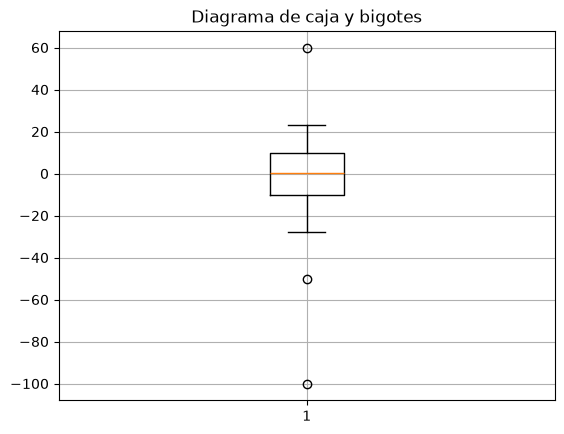

In [10]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de␣outliers
plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()

In [11]:
# Medidas de dispersión
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)

Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


In [14]:
# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [17]:
# Cargar el set de datos de Iris
from sklearn import datasets
from pprint import pprint
iris = datasets.load_iris()
pprint(iris)
X = iris.data
y = iris.target
# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?
#???
# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según␣su curtosis?
#???

{'DESCR': '.. _iris_dataset:\n'
          '\n'
          'Iris plants dataset\n'
          '--------------------\n'
          '\n'
          '**Data Set Characteristics:**\n'
          '\n'
          ':Number of Instances: 150 (50 in each of three classes)\n'
          ':Number of Attributes: 4 numeric, predictive attributes and the '
          'class\n'
          ':Attribute Information:\n'
          '    - sepal length in cm\n'
          '    - sepal width in cm\n'
          '    - petal length in cm\n'
          '    - petal width in cm\n'
          '    - class:\n'
          '            - Iris-Setosa\n'
          '            - Iris-Versicolour\n'
          '            - Iris-Virginica\n'
          '\n'
          ':Summary Statistics:\n'
          '\n'
          '============== ==== ==== ======= ===== ====================\n'
          '                Min  Max   Mean    SD   Class Correlation\n'
          '============== ==== ==== ======= ===== ====================\n'
          '

In [ ]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la␣clase y representarlo en un gráfico (plt.errorbar)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# 1. CARGAR IRIS CON SEABORN 
iris = sns.load_dataset('iris')
# Nombres de las variables numéricas
variables = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
clases    = iris['species'].unique()  # ['setosa', 'versicolor', 'virginica']

In [22]:
# 2. MEDIA Y DESVIACIÓN TÍPICA POR CLASE CON PANDAS 
media_clase = iris.groupby('species')[variables].mean()
std_clase   = iris.groupby('species')[variables].std()
print("── MEDIAS POR CLASE ──")
print(media_clase)
print("\n── DESVIACIÓN TÍPICA POR CLASE ──")
print(std_clase)

── MEDIAS POR CLASE ──
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026

── DESVIACIÓN TÍPICA POR CLASE ──
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          0.352490     0.379064      0.173664     0.105386
versicolor      0.516171     0.313798      0.469911     0.197753
virginica       0.635880     0.322497      0.551895     0.274650


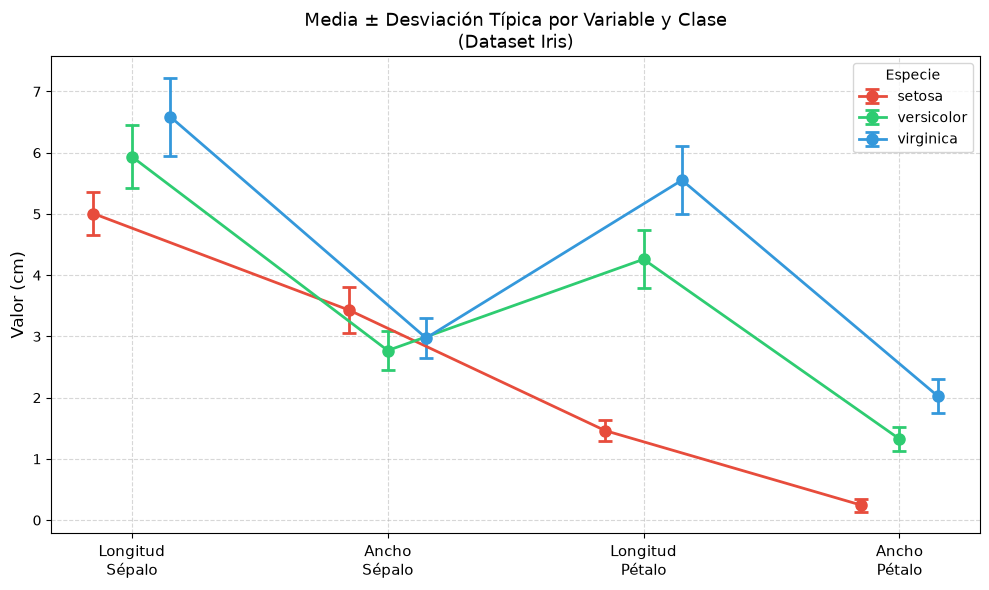

In [23]:
# 3. GRÁFICO CON plt.errorbar 
fig, ax = plt.subplots(figsize=(10, 6))
colores = {'setosa': '#e74c3c', 'versicolor': '#2ecc71', 'virginica': '#3498db'}
x = np.arange(len(variables))   # posiciones en eje X: 0,1,2,3
offset = [-0.15, 0, 0.15]       # separar las 3 clases visualmente
for i, clase in enumerate(clases):
    medias = media_clase.loc[clase].values
    stds   = std_clase.loc[clase].values
    ax.errorbar(
        x + offset[i],        # posición X con desplazamiento
        medias,                # valor Y (media)
        yerr=stds,             # barra de error (desv. típica)
        fmt='o-',              # círculo + línea
        color=colores[clase],
        label=clase,
        capsize=5,             # tapa de la barra de error
        linewidth=2,
        markersize=8,
        capthick=2
    )
# Etiquetas
etiquetas = ['Longitud\nSépalo', 'Ancho\nSépalo', 'Longitud\nPétalo', 'Ancho\nPétalo']
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylabel('Valor (cm)', fontsize=12)
ax.set_title('Media ± Desviación Típica por Variable y Clase\n(Dataset Iris)', fontsize=13)
ax.legend(title='Especie', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()